In [15]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.fftpack import dct , idct
import cv2
import heapq
from collections import Counter

In [29]:
img = cv2.imread('img1.png' , cv2.IMREAD_COLOR)

In [17]:
QUANTIZATION_TABLE = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)

ZIGZAG_ORDER = np.array([
    [0,  1,  5,  6,  14, 15, 27, 28],
    [2,  4,  7,  13, 16, 26, 29, 42],
    [3,  8,  12, 17, 25, 30, 41, 43],
    [9,  11, 18, 24, 31, 40, 44, 53],
    [10, 19, 23, 32, 39, 45, 52, 54],
    [20, 22, 33, 38, 46, 51, 55, 60],
    [21, 34, 37, 47, 50, 56, 59, 61],
    [35, 36, 48, 49, 57, 58, 62, 63]
])

def adjust_quantization_table(quality):
    if quality <= 0:
        quality = 1
    if quality > 100:
        quality = 100

    scale_factor = 0
    if quality < 50:
        scale_factor = 50.0 / quality
    else:
        scale_factor = (100 - quality) / 50.0
    
    quant_table = QUANTIZATION_TABLE * scale_factor
    quant_table = np.clip(quant_table, 1, 255)
    quant_table = np.round(quant_table).astype(np.int32)
    
    return quant_table

In [32]:
img1 = img.astype(np.float32)

img1.shape


AttributeError: 'NoneType' object has no attribute 'astype'

In [ ]:
def rgb_to_ycbcr(image):
    # More accurate conversion matrix
    transform_matrix = np.array([
        [0.299, 0.587, 0.114],
        [-0.168736, -0.331264, 0.5],
        [0.5, -0.418688, -0.081312]])
    
    ycbcr = np.zeros_like(image, dtype=np.float32)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            rgb = image[i, j] / 255.0  # Normalize to [0,1]
            ycbcr[i, j] = np.dot(transform_matrix, rgb) * 255 + np.array([0, 128, 128])
    
    return np.clip(ycbcr, 0, 255).astype(np.uint8)

In [19]:
def ycbcr_to_rgb(ycbcr_image):
    inv_transform_matrix = np.array([
        [1.0, 0.0, 1.402],
        [1.0, -0.344136, -0.714136],
        [1.0, 1.772, 0.0]])
    
    rgb = np.zeros_like(ycbcr_image, dtype=np.float32)
    ycbcr = ycbcr_image.astype(np.float32)
    
    for i in range(ycbcr.shape[0]):
        for j in range(ycbcr.shape[1]):
            ycbcr_pixel = (ycbcr[i, j] - np.array([0, 128, 128])) / 255.0
            rgb[i, j] = np.dot(inv_transform_matrix, ycbcr_pixel) * 255
    
    return np.clip(rgb, 0, 255).astype(np.uint8)

In [20]:
def down_sample_color(ycbcr_image, sampling_factor=2):
    height, width = ycbcr_image.shape[:2]
    y_component = ycbcr_image[:, :, 0]
    cb_down = cv2.resize(ycbcr_image[:, :, 1], (width // sampling_factor, height // sampling_factor), interpolation=cv2.INTER_AREA)
    cr_down = cv2.resize(ycbcr_image[:, :, 2], (width // sampling_factor, height // sampling_factor), interpolation=cv2.INTER_AREA)
    
    return y_component, cb_down, cr_down

In [21]:
def upsample_chroma_420_to_444(y, cb, cr):
    h, w = y.shape
    cb_upsampled = cv2.resize(cb, (w, h), interpolation=cv2.INTER_LINEAR)
    cr_upsampled = cv2.resize(cr, (w, h), interpolation=cv2.INTER_LINEAR)
    
    return y, cb_upsampled, cr_upsampled

In [22]:
def partition_into_8x8_blocks(component):
    height, width = component.shape
    block_size = 8
    pad_height = (block_size - height % block_size) % block_size
    pad_width = (block_size - width % block_size) % block_size
    padded = np.pad(component, ((0, pad_height), (0, pad_width)), mode='edge')
    blocks = []
    h, w = padded.shape
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = padded[i:i+block_size, j:j+block_size]
            blocks.append(block)
    
    return blocks, padded.shape

In [23]:
def forward_dct(blocks):
    dct_blocks = []
    for block in blocks:
        block_shifted = block.astype(np.float32) - 128
        dct_block = dct(dct(block_shifted.T, norm='ortho').T, norm='ortho')
        dct_blocks.append(dct_block)
    return dct_blocks

In [24]:
def quantize(dct_blocks, quant_table, quality=85):
    if quality < 50:
        scale = 50.0 / quality
    else:
        scale = 2 - quality / 50.0
    adjusted_quant_table = quant_table * scale
    adjusted_quant_table = np.clip(adjusted_quant_table, 1, 255)
    adjusted_quant_table = np.round(adjusted_quant_table).astype(np.int32)
    quantized_blocks = []
    for block in dct_blocks:
        quantized_block = np.round(block / adjusted_quant_table)
        quantized_blocks.append(quantized_block)
    
    return quantized_blocks, adjusted_quant_table

In [25]:
class HuffmanNode:
    def __init__(self, symbol, freq):
        self.symbol = symbol
        self.freq = freq
        self.left = None
        self.right = None
    def __lt__(self, other):
        return self.freq < other.freq

def zigzag_scan(block):
    zigzag = []
    for i in range(8):
        for j in range(8):
            idx = ZIGZAG_ORDER[i][j]
            row = idx // 8
            col = idx % 8
            zigzag.append(block[row][col])
    return np.array(zigzag)

def run_length_encode(zigzag_array):
    rle = []
    zero_count = 0
    
    for value in zigzag_array:
        if value == 0:
            zero_count += 1
        else:
            rle.append((zero_count, value))
            zero_count = 0

    rle.append((0, 0))
    return rle

def build_huffman_tree(freq_dict):
    heap = [HuffmanNode(symbol, freq) for symbol, freq in freq_dict.items()]
    heapq.heapify(heap)
    
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = HuffmanNode(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)
    
    return heap[0]

def build_huffman_codes(node, current_code="", codes=None):

    if codes is None:
        codes = {}
    if node.symbol is not None:
        codes[node.symbol] = current_code
    else:
        build_huffman_codes(node.left, current_code + "0", codes)
        build_huffman_codes(node.right, current_code + "1", codes)
    return codes

def entropy_encoder(quantized_blocks_y, quantized_blocks_cb, quantized_blocks_cr):
   
    all_rle_data = []
    for block in quantized_blocks_y:
        zigzag = zigzag_scan(block)
        rle_block = run_length_encode(zigzag)
        all_rle_data.extend(rle_block)
    for block in quantized_blocks_cb:
        zigzag = zigzag_scan(block)
        rle_block = run_length_encode(zigzag)
        all_rle_data.extend(rle_block)

    for block in quantized_blocks_cr:
        zigzag = zigzag_scan(block)
        rle_block = run_length_encode(zigzag)
        all_rle_data.extend(rle_block)
    
    freq_dict = Counter(all_rle_data)
    huffman_tree = build_huffman_tree(freq_dict)
    huffman_codes = build_huffman_codes(huffman_tree)
    
    encoded_bits = ""
    for symbol in all_rle_data:
        encoded_bits += huffman_codes[symbol]
    
    return encoded_bits, huffman_tree, all_rle_data


def jpeg_compress_complete(img, quality=85):
    ycbcr_img = rgb_to_ycbcr(img)
    y_component, cb_down, cr_down = down_sample_color(ycbcr_img, sampling_factor=2)
    
    blocks_y, y_shape = partition_into_8x8_blocks(y_component)
    blocks_cb, cb_shape = partition_into_8x8_blocks(cb_down)
    blocks_cr, cr_shape = partition_into_8x8_blocks(cr_down)
    
    dct_blocks_y = forward_dct(blocks_y)
    dct_blocks_cb = forward_dct(blocks_cb)
    dct_blocks_cr = forward_dct(blocks_cr)
    
    quant_blocks_y, quant_table = quantize(dct_blocks_y, QUANTIZATION_TABLE, quality)
    quant_blocks_cb, _ = quantize(dct_blocks_cb, QUANTIZATION_TABLE, quality)
    quant_blocks_cr, _ = quantize(dct_blocks_cr, QUANTIZATION_TABLE, quality)
    
    compressed_bits, huffman_tree, rle_data = entropy_encoder(
        quant_blocks_y, quant_blocks_cb, quant_blocks_cr)
    
    compression_data = {
        'compressed_bits': compressed_bits,
        'huffman_tree': huffman_tree,
        'quant_table': quant_table,
        'y_shape': y_component.shape,  
        'cb_shape': cb_down.shape,
        'cr_shape': cr_down.shape,
        'original_shape': img.shape[:2],  
        'rle_data': rle_data
    }
    
    return compression_data

def calculate_compression_metrics(original_img, compressed_bits, rle_data):
    original_size = original_img.size * 8 
    compressed_size = len(compressed_bits)
    compression_ratio = (compressed_size / original_size)*100
    print(f"Original size: {original_size:,} bits")
    print(f"Compressed size: {compressed_size:,} bits")
    print(f"Compression ratio: {compression_ratio:.2f}%")


compression_data = jpeg_compress_complete(img, quality=85)
calculate_compression_metrics(img, compression_data['compressed_bits'],  compression_data['rle_data'])


AttributeError: 'NoneType' object has no attribute 'len'

In [ ]:
def decode_huffman(encoded_bits, huffman_tree):
    decoded_symbols = []
    current_node = huffman_tree
    for bit in encoded_bits:
        if bit == '0':
            current_node = current_node.left
        else:
            current_node = current_node.right
        
        if current_node.symbol is not None:
            decoded_symbols.append(current_node.symbol)
            current_node = huffman_tree
    
    return decoded_symbols

In [ ]:
def run_length_decode(rle_data):
    zigzag_arrays = []
    current_block = []
    zero_count = 0
    
    for zero_run, value in rle_data:
        if zero_run == 0 and value == 0:
            while len(current_block) < 64:
                current_block.append(0)
            if current_block:
                zigzag_arrays.append(np.array(current_block))
                current_block = []
            continue
        
        for _ in range(zero_run):
            current_block.append(0)
        
        current_block.append(value)
    
    return zigzag_arrays

In [ ]:
def run_length_encode(zigzag_array):
    rle = []
    zero_count = 0
    
    for value in zigzag_array:
        if value == 0:
            zero_count += 1
        else:
            rle.append((zero_count, value))
            zero_count = 0
    
    # End of block marker
    if zero_count > 0 or len(rle) == 0 or rle[-1] != (0, 0):
        rle.append((0, 0))
    
    return rle

In [ ]:
def inverse_zigzag_scan(zigzag_array):
    block = np.zeros((8, 8))
    for i in range(8):
        for j in range(8):
            idx = ZIGZAG_ORDER[i][j]
            row = idx // 8
            col = idx % 8
            block[row][col] = zigzag_array[i * 8 + j]
    return block

In [ ]:
def dequantize(quantized_blocks, quant_table):
    dequantized_blocks = []
    for block in quantized_blocks:
        dequant_block = block * quant_table
        dequantized_blocks.append(dequant_block)
    return dequantized_blocks

In [ ]:
def inverse_dct(dct_blocks):
    idct_blocks = []
    for block in dct_blocks:
        idct_block = idct(idct(block.T, norm='ortho').T, norm='ortho')
        # Level shift back to [0,255]
        idct_block = np.clip(idct_block + 128, 0, 255)
        idct_blocks.append(idct_block)
    return idct_blocks

In [ ]:
def reassemble_blocks(blocks, original_shape):
    block_size = 8
    height, width = original_shape
    
    # Calculate padded dimensions
    padded_height = ((height + block_size - 1) // block_size) * block_size
    padded_width = ((width + block_size - 1) // block_size) * block_size
    
    reconstructed = np.zeros((padded_height, padded_width))
    block_idx = 0
    
    for i in range(0, padded_height, block_size):
        for j in range(0, padded_width, block_size):
            if block_idx < len(blocks):
                reconstructed[i:i+block_size, j:j+block_size] = blocks[block_idx]
                block_idx += 1
    
    # Return only the original dimensions
    return reconstructed[:height, :width]

In [ ]:

def jpeg_decompress_complete(compression_data):
    decoded_symbols = decode_huffman(compression_data['compressed_bits'], compression_data['huffman_tree'])
    zigzag_arrays = run_length_decode(decoded_symbols)
    
    # Calculate blocks for each component based on original shapes
    y_blocks_count = compression_data['y_shape'][0] * compression_data['y_shape'][1] // 64
    cb_blocks_count = compression_data['cb_shape'][0] * compression_data['cb_shape'][1] // 64
    cr_blocks_count = compression_data['cr_shape'][0] * compression_data['cr_shape'][1] // 64
    
    zigzag_y = zigzag_arrays[:y_blocks_count]
    zigzag_cb = zigzag_arrays[y_blocks_count:y_blocks_count + cb_blocks_count]
    zigzag_cr = zigzag_arrays[y_blocks_count + cb_blocks_count:y_blocks_count + cb_blocks_count + cr_blocks_count]
    
    quant_blocks_y = [inverse_zigzag_scan(zigzag) for zigzag in zigzag_y]
    quant_blocks_cb = [inverse_zigzag_scan(zigzag) for zigzag in zigzag_cb]
    quant_blocks_cr = [inverse_zigzag_scan(zigzag) for zigzag in zigzag_cr]

    dequant_blocks_y = dequantize(quant_blocks_y, compression_data['quant_table'])
    dequant_blocks_cb = dequantize(quant_blocks_cb, compression_data['quant_table'])
    dequant_blocks_cr = dequantize(quant_blocks_cr, compression_data['quant_table'])
    
    idct_blocks_y = inverse_dct(dequant_blocks_y)
    idct_blocks_cb = inverse_dct(dequant_blocks_cb)
    idct_blocks_cr = inverse_dct(dequant_blocks_cr)
    
    y_reconstructed = reassemble_blocks(idct_blocks_y, compression_data['y_shape'])
    cb_reconstructed = reassemble_blocks(idct_blocks_cb, compression_data['cb_shape'])
    cr_reconstructed = reassemble_blocks(idct_blocks_cr, compression_data['cr_shape'])
    
    y_upsampled, cb_upsampled, cr_upsampled = upsample_chroma_420_to_444(y_reconstructed, cb_reconstructed, cr_reconstructed)
    
    ycbcr_reconstructed = np.stack([y_upsampled, cb_upsampled, cr_upsampled], axis=2)
    
    rgb_reconstructed = ycbcr_to_rgb(ycbcr_reconstructed)
    
    return rgb_reconstructed



In [ ]:
def validate_compression(img, compressed_data):
    print(f"Original shape: {img.shape}")
    print(f"Y shape: {compressed_data['y_shape']}")
    print(f"Cb shape: {compressed_data['cb_shape']}")
    print(f"Cr shape: {compressed_data['cr_shape']}")
    
    # Check if all components were processed
    total_blocks = len(compressed_data['rle_data'])
    expected_blocks = (compressed_data['y_shape'][0] * compressed_data['y_shape'][1] + 
                      compressed_data['cb_shape'][0] * compressed_data['cb_shape'][1] + 
                      compressed_data['cr_shape'][0] * compressed_data['cr_shape'][1]) // 64
    print(f"Total blocks in RLE: {total_blocks}, Expected: {expected_blocks}")

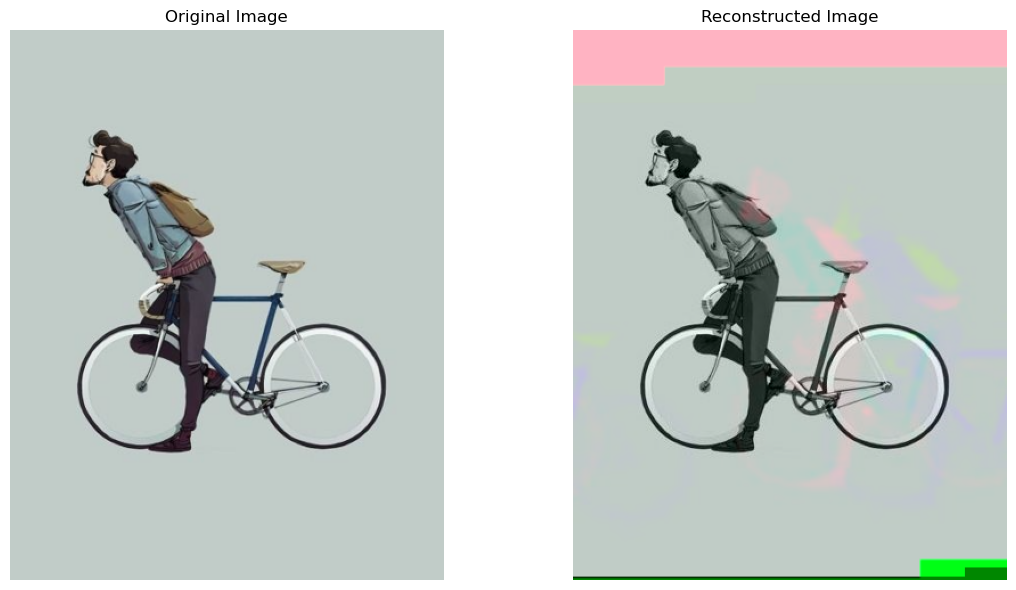

Original size: 4,416,552 bits
Compressed size: 141,776 bits
Compression ratio: 3.21%


In [ ]:
compression_data = jpeg_compress_complete(img, quality=85)
reconstructed_img = jpeg_decompress_complete(compression_data)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(reconstructed_img, cv2.COLOR_BGR2RGB))
plt.title('Reconstructed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

calculate_compression_metrics(img, compression_data['compressed_bits'], compression_data['rle_data'])